# 2. 포물선과 직선의 위치 관계

포물선 $y^2=4px$와 직선 $y=mx+n$의 교점은

$$
(mx+n)^2 = 4px \quad\Rightarrow\quad m^2x^2 + (2mn-4p)x + n^2 = 0
$$

판별식 $D$에 따라 **교점 0, 1, 2개**(접, 이등, 교차).


## 1. 판별식

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x, m, n, p = sp.symbols('x m n p', real=True)
p_pos = sp.symbols('p', positive=True)

# y^2=4px, y=mx+n → m^2 x^2 + (2mn-4p)x + n^2 = 0
D = sp.expand((2*m*n - 4*p_pos)**2 - 4*m**2*n**2)
print("판별식 D =")
display(D)

# D = 16p(m^2 x - n) when expanded differently; standard form:
D_std = sp.expand((2*m*n - 4*p_pos)**2 - 4*(m**2)*(n**2))
print("정리:", sp.factor(D_std))

판별식 D =


정리: 16*p*(-m*n + p)


**sp.expand(expr)**: <br>
=> 다항식 전개

**sp.factor(expr)**: <br>
=> 인수분해


## 2. 위치 관계 예시

m=0, n=1: D=16.00, 교점 2개 (교차)
m=1, n=0.5: D=8.00, 교점 2개 (접)
m=0, n=-0.5: D=16.00, 교점 2개 (이등)


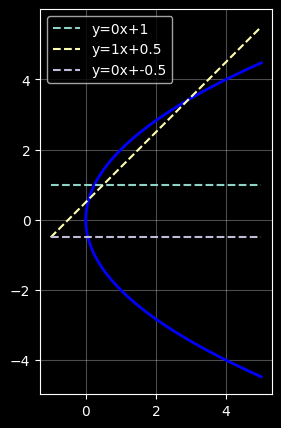

In [2]:
p_val = 1

def count_intersections(m_val, n_val):
    a, b, c = m_val**2, 2*m_val*n_val - 4*p_val, n_val**2
    D = b**2 - 4*a*c
    if D < 0: return 0, D
    if D == 0: return 1, D
    return 2, D

cases = [(0, 1, '교차'), (1, 0.5, '접'), (0, -0.5, '이등')]
for m_v, n_v, label in cases:
    cnt, D = count_intersections(m_v, n_v)
    print(f"m={m_v}, n={n_v}: D={D:.2f}, 교점 {cnt}개 ({label})")

fig, ax = plt.subplots(figsize=(7, 5))
t = np.linspace(0, 5, 300)
y_p = np.sqrt(4 * p_val * t)
ax.plot(t, y_p, 'b', lw=2); ax.plot(t, -y_p, 'b', lw=2)
for m_v, n_v, _ in cases:
    xs = np.linspace(-1, 5, 100)
    ax.plot(xs, m_v*xs + n_v, '--', label=f'y={m_v}x+{n_v}')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
plt.show()